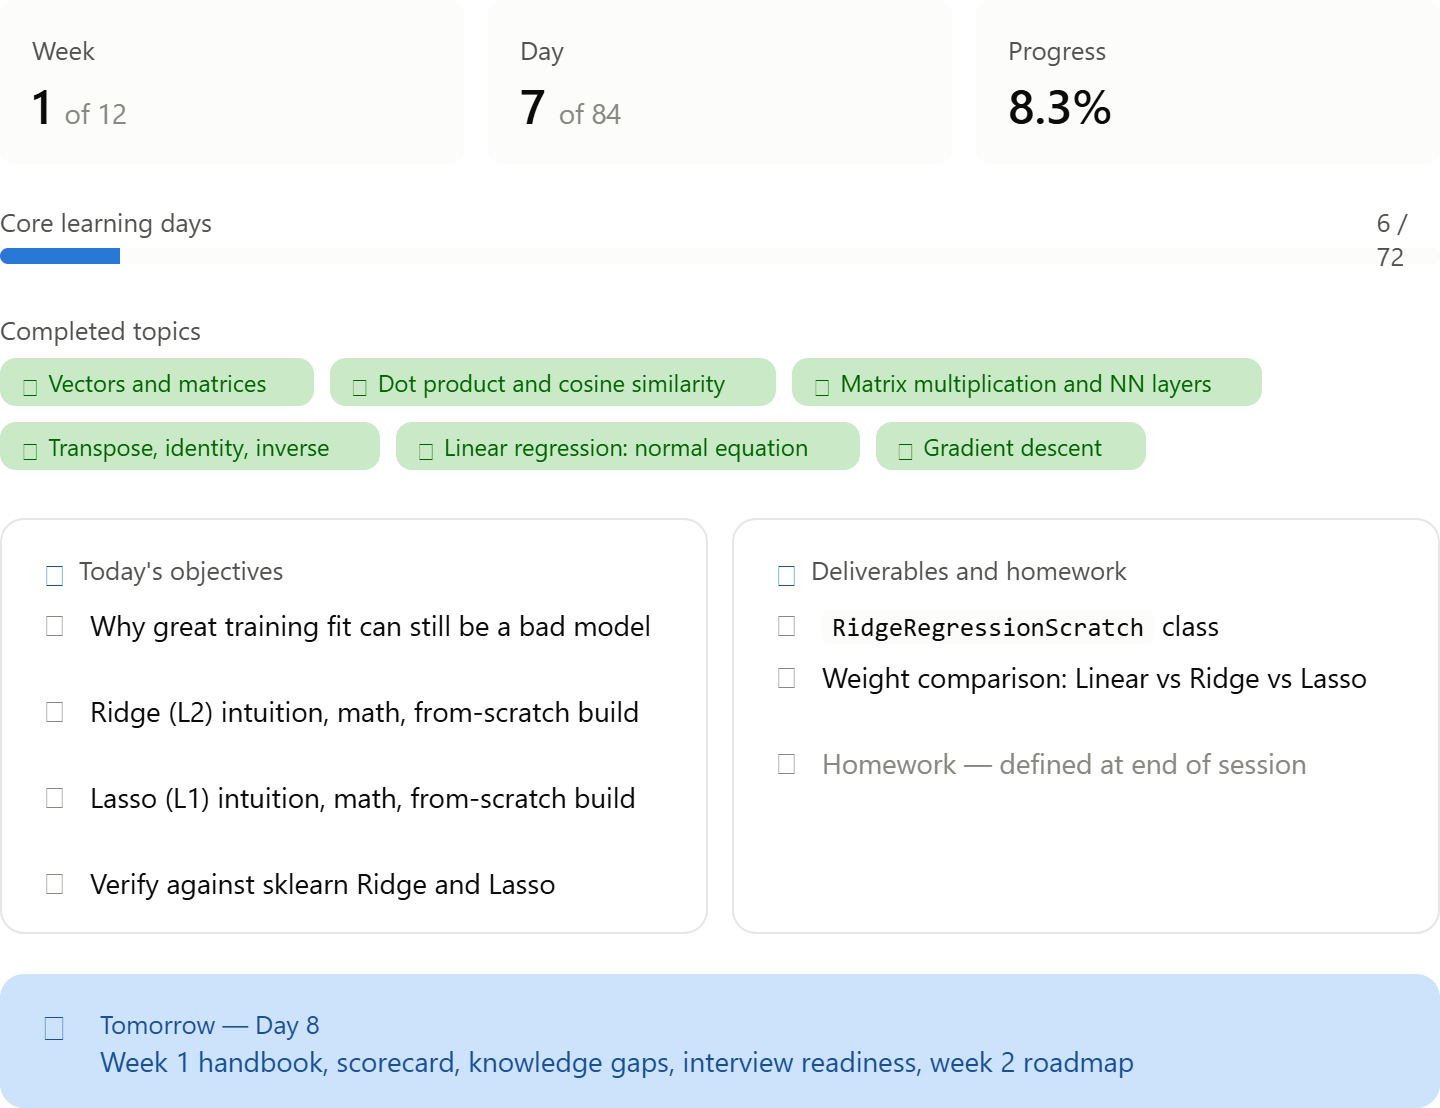

### Ridge Regression

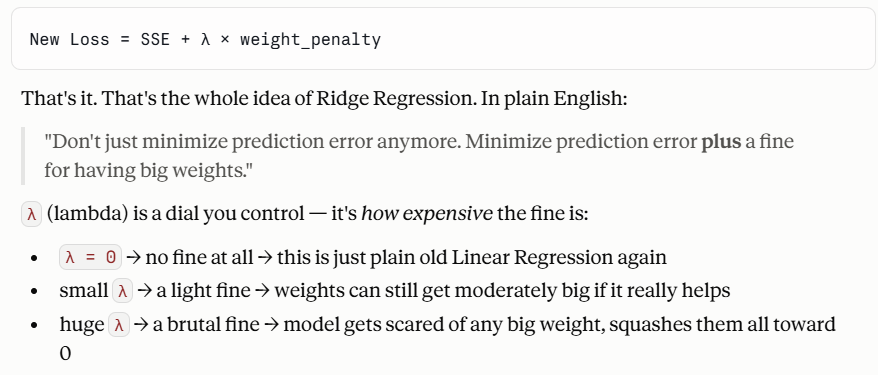

In [2]:
import numpy as np

class RidgeRegressionScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y

        n_features = X_b.shape[1]        # includes the bias column
        I = np.eye(n_features)
        I[0, 0] = 0                      # don't penalize the bias term

        self.w = np.linalg.inv(XtX + self.alpha * I) @ Xty
        return self

    def predict(self, X):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        return X_b @ self.w

In [3]:
# student dataset from Day 5: study_hours, sleep_hours, practice_tests -> exam_score
X = np.array([
    [1, 6, 1],
    [2, 7, 2],
    [3, 6, 2],
    [4, 8, 3],
    [5, 7, 4],
    [6, 8, 5],
    [7, 9, 6],
], dtype=float)
y = np.array([50, 55, 60, 68, 72, 80, 88], dtype=float)

In [4]:
alphas = [0, 1, 10, 100]
weights_by_alpha = {}

In [5]:
for alpha in alphas:
    model = RidgeRegressionScratch(alpha=alpha)
    model.fit(X, y)
    weights_by_alpha[alpha] = model.w
    print(f"alpha={alpha:>5} -> weights={np.round(model.w, 4)}")

alpha=    0 -> weights=[35.5909  4.8636  1.2273  1.0909]
alpha=    1 -> weights=[36.7838  3.7027  1.1081  2.4054]
alpha=   10 -> weights=[39.9906  2.8708  1.1737  2.2967]
alpha=  100 -> weights=[56.0818  1.1555  0.5124  0.954 ]


### Lasso Regression

In [6]:
class LassoRegressionScratch:
    def __init__(self, alpha=1.0, n_iterations=1000):
        self.alpha = alpha
        self.n_iterations = n_iterations

    def fit(self, X, y):
        self.mean_X = X.mean(axis=0)
        self.mean_y = y.mean()
        X_c = X - self.mean_X
        y_c = y - self.mean_y

        n_samples, n_features = X_c.shape
        self.w = np.zeros(n_features)     # start every weight at 0, same as GradientDescentScratch did

        def soft_threshold(rho, threshold):
                if rho > threshold:
                    return rho - threshold
                elif rho < -threshold:
                    return rho + threshold
                else:
                    return 0

        threshold = n_samples * self.alpha

        for iteration in range(self.n_iterations):
            for j in range(n_features):
                residual = y_c - X_c @ self.w + X_c[:, j] * self.w[j]
                rho_j = X_c[:, j] @ residual
                z_j = np.sum(X_c[:, j] ** 2)
                self.w[j] = soft_threshold(rho_j, threshold) / z_j

        self.bias = self.mean_y - self.mean_X @ self.w
        return self

    def predict(self, X):
        return X @ self.w + self.bias

In [7]:
# ---- Student dataset: study_hours, sleep_hours, practice_tests -> exam_score ----
X = np.array([
    [2, 5, 1],
    [4, 6, 2],
    [6, 7, 2],
    [8, 6, 3],
    [3, 4, 1],
    [5, 8, 3],
    [7, 5, 4]
], dtype=float)

y = np.array([42, 55, 68, 78, 45, 72, 75], dtype=float)

study_minutes = X[:, 0] * 60
X = np.hstack([X, study_minutes.reshape(-1, 1)])   # shape (7, 4)
X

array([[  2.,   5.,   1., 120.],
       [  4.,   6.,   2., 240.],
       [  6.,   7.,   2., 360.],
       [  8.,   6.,   3., 480.],
       [  3.,   4.,   1., 180.],
       [  5.,   8.,   3., 300.],
       [  7.,   5.,   4., 420.]])

In [8]:
alphas = [0, 1, 10, 100]
weights_by_alpha = {}

for alpha in alphas:
    model = LassoRegressionScratch(alpha=alpha)
    model.fit(X, y)
    weights_by_alpha[alpha] = model.w
    print(f"alpha={alpha:>3} -> weights={np.round(model.w, 4)}")

alpha=  0 -> weights=[ 6.4643  2.6609  4.0435 -0.0384]
alpha=  1 -> weights=[0.     2.1471 1.1634 0.0917]
alpha= 10 -> weights=[0.    0.    0.    0.107]
alpha=100 -> weights=[0.     0.     0.     0.1008]


In [9]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

In [10]:
alphas = [0, 1, 10, 100]
weights_by_alpha_scaled = {}

for alpha in alphas:
    model = LassoRegressionScratch(alpha=alpha)
    model.fit(X_scaled, y)
    weights_by_alpha_scaled[alpha] = model.w
    print(f"alpha={alpha:>3} -> weights={np.round(model.w, 4)}")

alpha=  0 -> weights=[12.9286  3.3139  4.1654 -4.6062]
alpha=  1 -> weights=[7.8683 2.6026 3.8034 0.    ]
alpha= 10 -> weights=[2.9286 0.     0.     0.    ]
alpha=100 -> weights=[0. 0. 0. 0.]


In [14]:
from sklearn.linear_model import Ridge, Lasso

ridge_sk = Ridge(alpha=10).fit(X, y)
lasso_sk = Lasso(alpha=10).fit(X_scaled, y)

print("Ridge scratch:", np.round(RidgeRegressionScratch(alpha=10).fit(X, y).w, 4))
print("Ridge sklearn:", np.round(np.r_[ridge_sk.intercept_, ridge_sk.coef_], 4))

print("Lasso scratch:", np.round(LassoRegressionScratch(alpha=10).fit(X_scaled, y).w, 4))
print("Lasso sklearn:", np.round(lasso_sk.coef_, 4))

Ridge scratch: [2.29157e+01 1.60000e-03 1.41900e+00 8.25000e-01 9.67000e-02]
Ridge sklearn: [2.29157e+01 1.60000e-03 1.41900e+00 8.25000e-01 9.67000e-02]
Lasso scratch: [2.9286 0.     0.     0.    ]
Lasso sklearn: [2.9286 0.     0.     0.    ]
